## 0. Setup

In [1]:
INDIA_PROJECTED_CRS = "24378"

In [2]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [3]:
# general
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm.notebook import tqdm

# for plotting and coloring
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import matplotlib.cm

# for handling S2 cells and downloading VIDA data
import boto3
from s2cell.s2cell import lat_lon_to_cell_id
import s2sphere
from shapely.geometry import Polygon

gpd.options.io_engine = "pyogrio"

In [4]:
from gridsample.utils import create_ids, create_gmap_links, save_shapefiles
# from gridsample.mapping import create_interactive_map

In [6]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "01. Raw Data"
CLEANED_DATA_DIR = DATA_DIR / "02. Intermediate Outputs"
OUTPUT_DATA_DIR = DATA_DIR / "03. Final Outputs" / "v16_replacements"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
def generate_colormap(N):
    arr = np.arange(N) / N
    N_up = int(math.ceil(N / 7) * 7)
    arr.resize(N_up)
    arr = arr.reshape(7, N_up // 7).T.reshape(-1)
    ret = matplotlib.cm.hsv(arr)
    n = ret[:, 3].size
    a = n // 2
    b = n - a

    # Create arrays of exactly matching sizes
    for i in range(3):
        ret[0:a, i] *= np.linspace(0.2, 1, a)
    ret[a:, 3] *= np.linspace(1, 0.3, b)

    return ret[:N]  # Return only the requested number of colors

## 1. Load MapSolve boundaries

In [8]:
# get all filepaths that end in `gpkg` inside the RAW_DATA_DIR / 0.1. MapSolve Boundaries
boundaries_dir = RAW_DATA_DIR / "01. MapSolve Boundaries"
gpkg_files_all = list(boundaries_dir.glob("**/*.gpkg"))
gpkg_files_all = [f for f in gpkg_files_all if f.is_file()]
# # drop any with the word "Sub-District" in the filename
# gpkg_files_VTW = [f for f in gpkg_files_all if "Sub-District" not in f.name]
# load all shapes into one gdf
gdf_list = []
for filepath in gpkg_files_all:
    gdf_list.append(gpd.read_file(filepath))
gdf = pd.concat(gdf_list, ignore_index=True).to_crs(4326)

In [9]:
gdf.duplicated().sum()

22270

In [10]:
gdf = gdf.drop_duplicates()

<Axes: >

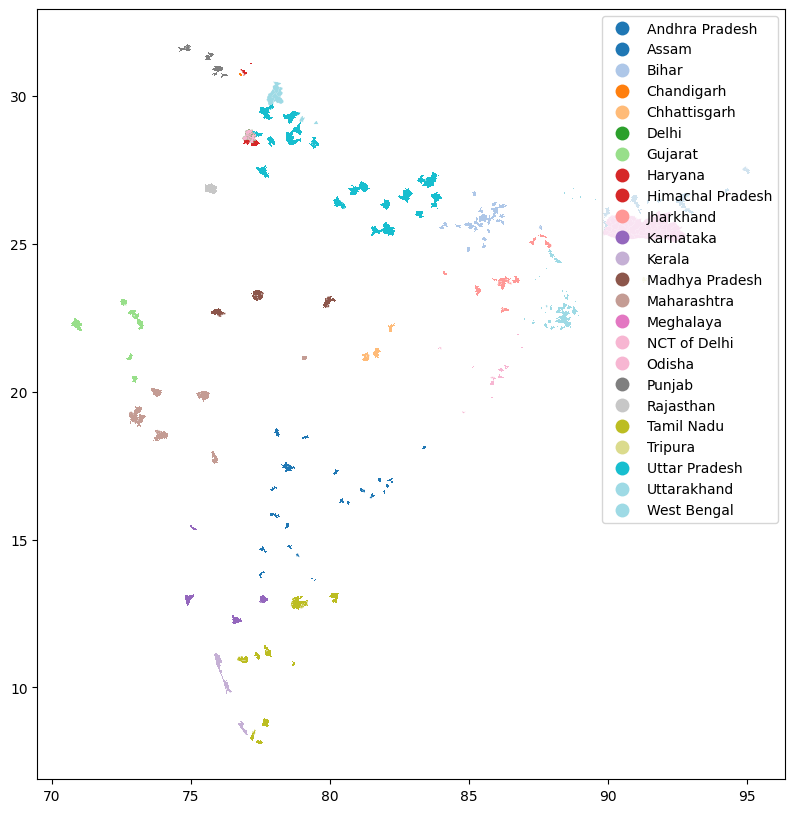

In [11]:
gdf.plot(column="State_N", legend=True, figsize=(10, 10), cmap="tab20")

## 2. Load sampled wards data

In [12]:
# load the merged wards data
sample_df = pd.read_csv(
    CLEANED_DATA_DIR
    / "00. Merge and Quality Checks"
    / "v9_corrected_counts"
    / "Merged Wards with Quality Checks.csv"
)

### 2.1 Rename and clean both datasets

In [13]:
rename_dict = {
    "UID": "UID",
    "PCA_ID": "PCA_ID",
    "State_C": "State Code",
    "State_N": "State Name",
    "Dist_C": "District Code",
    "Dist_N": "District Name",
    "SubDist_C": "Subdistrict Code",
    "SubDist_N": "Subdistrict Name",
    "TV_C": "TV Code",
    "TV_N": "TV Name",
    "Ward_C": "Ward Code",
    "TOT_P": "Total Population",
}

gdf = gdf.rename(columns=rename_dict)

In [14]:
rename_dict = {
    "State": "State Code",
    "State_Name": "State Name",
    "District": "District Code",
    "District_Name": "District Name",
    "Subdistrict": "Subdistrict Code",
    "Subd_Name": "Subdistrict Name",
    "TownVillage": "TV Code",
    "UrbanWardVillage": "Ward Code",
    "WardVillage_Name": "Ward/Village Name",
    "TRU": "Urban/Rural",
    "WardVillage_Pop": "Ward Population",
    "Subd_Pop": "Subdistrict Population",
    "State_Pop": "State Population",
    "WardVillageID": "Complete ID",
}
sample_df = sample_df.rename(columns=rename_dict)

# make State Name heading case instead of all caps
sample_df["State Name"] = sample_df["State Name"].str.title()
sample_df.loc[sample_df["State Name"] == "Nct Of Delhi", "State Name"] = "NCT of Delhi"

In [15]:
# make relevant codes into floats for both datasets
code_columns = [
    "State Code",
    "District Code",
    "Subdistrict Code",
    "TV Code",
    "Ward Code",
]
for col in code_columns:
    sample_df[col] = sample_df[col].astype(float)
    gdf[col] = gdf[col].astype(float)

In [16]:
sample_df

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,Ward Count IFS,Ward Count Panel,Ward Count Panel Round 2,Ward Count (All)
0,2.0,Himachal Pradesh,33.0,Shimla,182.0,Shimla (urban),800137.0,1.0,Shimla (M Corp.) WARD NO.-0001,800137-1,...,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,1,0,0,1
1,2.0,Himachal Pradesh,33.0,Shimla,182.0,Shimla (urban),800137.0,16.0,Shimla (M Corp.) WARD NO.-0016,800137-16,...,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,0,0,1,1
2,2.0,Himachal Pradesh,33.0,Shimla,182.0,Shimla (urban),800137.0,19.0,Shimla (M Corp.) WARD NO.-0019,800137-19,...,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,1,0,0,1
3,2.0,Himachal Pradesh,33.0,Shimla,182.0,Shimla (urban),800137.0,22.0,Shimla (M Corp.) WARD NO.-0022,800137-22,...,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,0,0,1,1
4,2.0,Himachal Pradesh,33.0,Shimla,182.0,Shimla (urban),800137.0,23.0,Shimla (M Corp.) WARD NO.-0023,800137-23,...,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1014,90.0,Telangana,537.0,Rangareddy,4523.0,Ghatkesar,574173.0,1.0,Peerzadguda (CT) WARD NO.-0001,574173-1,...,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,0,1,0,1
1015,90.0,Telangana,538.0,Mahbubnagar,4568.0,Mahbubnagar,802922.0,4.0,Mahbubnagar (M) WARD NO.-0004,802922-4,...,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,1,1,0,1
1016,90.0,Telangana,541.0,Khammam,4757.0,Khammam (Urban),579683.0,0.0,V. Venkatayapalem,579683-0,...,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,1,0,0,1
1017,90.0,Telangana,541.0,Khammam,4757.0,Khammam (Urban),579685.0,1.0,Khanapuram Haveli (CT) WARD NO.-0001,579685-1,...,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,0,1,0,1


## 3. Filter MapSolve boundaries to sampled areas

### 3.1 Filter to IFS and subset sample data to phase 2 states

In [17]:
# v12
# pca_ids = ["227556-0", "362170-0", "802312-10", "802776-82"]
# selected_states = ["Bihar", "Madhya Pradesh", "Jharkhand", "Maharashtra"]

# v13
# pca_ids = ["802813-1", "800441-46", "800441-49", "800441-236", "800441-126", "63999-43"] #not available:"63945-297"
# selected_states = ["Maharashtra", "NCT of Delhi"]

# v14
# pca_ids = ["63910-3", "800196-48", "802710-127"]
# tv_ids = [281676]
# selected_states = ["NCT of Delhi", "Assam", "Punjab", "Maharashtra"]

# # v15
# pca_ids = ["800441-74", "800441-162", "800441-129", "800441-152"]
# # tv_ids = [800441]
# selected_states = ["NCT of Delhi"]

# v16
pca_ids = ["64072-174", "64084-202", "63991-122", "800441-111"]
# tv_ids = [64072, 64084, 63991, 800441]
selected_states = ["NCT of Delhi"]

In [18]:
filtered_df = sample_df[sample_df["PCA_ID"].isin(pca_ids)].copy()

In [106]:
filtered_df[["Subdistrict Code", "TV Code", "Ward Code", "Delivery State"]]

,Subdistrict Code,TV Code,Ward Code,Delivery State
186,448.0,63991.0,122.0,GOOD - Subdistrict boundary given as expected
195,449.0,800441.0,111.0,GOOD - Ward boundary given as expected
224,454.0,64072.0,174.0,GOOD - Subdistrict boundary given as expected
239,456.0,64084.0,202.0,GOOD - Subdistrict boundary given as expected


### 3.2 Drop unnecessary rows 

#### Drop rows with no MapSolve shapes

In [21]:
filtered_df = filtered_df[filtered_df["PSU Type"] != "none"]

In [22]:
filtered_df

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,Ward Count IFS,Ward Count Panel,Ward Count Panel Round 2,Ward Count (All)
186,7.0,NCT of Delhi,96.0,West,448.0,Patel Nagar,63991.0,122.0,Hastsal (CT) WARD NO.-0122,63991-122,...,No,False,False,True,GOOD - Subdistrict boundary given as expected,subdistrict,0,0,1,1
195,7.0,NCT of Delhi,96.0,West,449.0,Rajouri Garden,800441.0,111.0,DMC (U) (Part) WARD NO.-0111,800441-111,...,No,True,False,True,GOOD - Ward boundary given as expected,ward,0,0,1,1
224,7.0,NCT of Delhi,98.0,South,454.0,Hauz Khas,64072.0,174.0,Sultan Pur (CT) WARD NO.-0174,64072-174,...,No,False,False,True,GOOD - Subdistrict boundary given as expected,subdistrict,0,0,4,5
239,7.0,NCT of Delhi,98.0,South,456.0,Kalkaji,64084.0,202.0,Mithe Pur (CT) WARD NO.-0202,64084-202,...,No,False,False,True,GOOD - Subdistrict boundary given as expected,subdistrict,0,0,3,3


In [23]:
# check bad rows, leave as is though
filtered_df[filtered_df["Delivery State"].str.contains("BAD")]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,Ward Count IFS,Ward Count Panel,Ward Count Panel Round 2,Ward Count (All)


#### Drop duplicate rows if PSU is TV or Subdistrict

In [24]:
filtered_df = filtered_df[
    # if the PSU Type is "town_village", then drop any duplicated rows with the same TV Code
    ~(
        (filtered_df["PSU Type"] == "town_village")
        & (filtered_df.duplicated(subset=["TV Code"], keep="first"))
    )
    # similar for subdistrict
    & ~(
        (filtered_df["PSU Type"] == "subdistrict")
        & (filtered_df.duplicated(subset=["Subdistrict Code"], keep="first"))
    )
]

filtered_df.value_counts("PSU Type")

PSU Type
subdistrict    3
ward           1
Name: count, dtype: int64

#### Duplicated wards

In [25]:
filtered_df[filtered_df["PCA_ID"].duplicated(keep=False)]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,Ward Count IFS,Ward Count Panel,Ward Count Panel Round 2,Ward Count (All)


In [26]:
print(f"Number of rows before dropping PCA_ID duplicates: {len(filtered_df)}")
print(
    f"Number of rows after dropping PCA_ID duplicates: {len(filtered_df.drop_duplicates(subset=['PCA_ID'], keep='first'))}"
)

Number of rows before dropping PCA_ID duplicates: 4
Number of rows after dropping PCA_ID duplicates: 4


In [27]:
filtered_df = filtered_df.drop_duplicates(subset=["PCA_ID"], keep="first")

In [28]:
filtered_df

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,Ward Count IFS,Ward Count Panel,Ward Count Panel Round 2,Ward Count (All)
186,7.0,NCT of Delhi,96.0,West,448.0,Patel Nagar,63991.0,122.0,Hastsal (CT) WARD NO.-0122,63991-122,...,No,False,False,True,GOOD - Subdistrict boundary given as expected,subdistrict,0,0,1,1
195,7.0,NCT of Delhi,96.0,West,449.0,Rajouri Garden,800441.0,111.0,DMC (U) (Part) WARD NO.-0111,800441-111,...,No,True,False,True,GOOD - Ward boundary given as expected,ward,0,0,1,1
224,7.0,NCT of Delhi,98.0,South,454.0,Hauz Khas,64072.0,174.0,Sultan Pur (CT) WARD NO.-0174,64072-174,...,No,False,False,True,GOOD - Subdistrict boundary given as expected,subdistrict,0,0,4,5
239,7.0,NCT of Delhi,98.0,South,456.0,Kalkaji,64084.0,202.0,Mithe Pur (CT) WARD NO.-0202,64084-202,...,No,False,False,True,GOOD - Subdistrict boundary given as expected,subdistrict,0,0,3,3


## 4. Merge shapes at the respective PSU level

### Wards

In [29]:
# PCA IDs to match (TVCode-WardCode)
pca_ids_to_match = filtered_df.loc[filtered_df["PSU Type"] == "ward", "PCA_ID"].unique()
len(pca_ids_to_match)

1

In [30]:
wards_gdf = gpd.GeoDataFrame(
    filtered_df[filtered_df["PSU Type"] == "ward"].merge(
        gdf[gdf["PCA_ID"].isin(pca_ids_to_match)],
        on=["PCA_ID"],
        how="left",
        suffixes=("", "_MapSolve"),
    ),
    geometry="geometry",
)
wards_gdf.shape

(1, 43)

### Town/Village

In [31]:
# TV codes to match
tv_codes_to_match = filtered_df.loc[
    filtered_df["PSU Type"] == "town_village", "TV Code"
].unique()
len(tv_codes_to_match)

0

In [32]:
tv_gdf = gpd.GeoDataFrame(
    filtered_df[filtered_df["PSU Type"] == "town_village"].merge(
        gdf[gdf["TV Code"].isin(tv_codes_to_match) & gdf["Ward Code"].isna()],
        on=["TV Code"],
        how="left",
        suffixes=("", "_MapSolve"),
    )
)
tv_gdf.shape

(0, 43)

In [33]:
# cut out the ward geometries from the TV geometries so we don't double sample those areas
trimmed_tv_geoms = tv_gdf.difference(wards_gdf.geometry.unary_union)
trimmed_tv_gdf = gpd.GeoDataFrame(
    tv_gdf.drop(columns="geometry").assign(geometry=trimmed_tv_geoms),
    crs=tv_gdf.crs,
)

### Subdistrict

In [34]:
# subdistrict codes to match
subdistrict_codes_to_match = filtered_df.loc[
    filtered_df["PSU Type"] == "subdistrict", "Subdistrict Code"
].unique()
len(subdistrict_codes_to_match)

3

In [35]:
subdistrict_gdf = gpd.GeoDataFrame(
    filtered_df[filtered_df["PSU Type"] == "subdistrict"].merge(
        gdf[
            gdf["Subdistrict Code"].isin(subdistrict_codes_to_match)
            & (gdf["TV Code"].isna())
            & (gdf["Ward Code"].isna())
        ],
        on=["Subdistrict Code"],
        how="left",
        suffixes=("", "_MapSolve"),
    )
)
subdistrict_gdf

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,State Code_MapSolve,State Name_MapSolve,District Code_MapSolve,District Name_MapSolve,Subdistrict Name_MapSolve,TV Code_MapSolve,TV Name,Ward Code_MapSolve,Total Population,geometry
0,7.0,NCT of Delhi,96.0,West,448.0,Patel Nagar,63991.0,122.0,Hastsal (CT) WARD NO.-0122,63991-122,...,7.0,NCT of Delhi,96.0,West,Patel Nagar,NaN,NaN,NaN,1262158.0,"MULTIPOLYGON (((77.03341 28.64619, 77.03368 28..."
1,7.0,NCT of Delhi,98.0,South,454.0,Hauz Khas,64072.0,174.0,Sultan Pur (CT) WARD NO.-0174,64072-174,...,7.0,NCT of Delhi,98.0,South,Hauz Khas (Saket),NaN,NaN,NaN,1219100.0,"MULTIPOLYGON (((77.21667 28.40989, 77.21667 28..."
2,7.0,NCT of Delhi,98.0,South,456.0,Kalkaji,64084.0,202.0,Mithe Pur (CT) WARD NO.-0202,64084-202,...,7.0,NCT of Delhi,98.0,South,Kalkaji,NaN,NaN,NaN,862861.0,"MULTIPOLYGON (((77.31988 28.48808, 77.31988 28..."


In [36]:
# cut out the TV and Ward geometries from the subdistrict geometries so we don't double sample those areas
combined_tv_and_ward_union_shape = wards_gdf.geometry.unary_union.union(
    trimmed_tv_gdf.geometry.unary_union
)
# trimmed_subdistrict_geoms = subdistrict_gdf.difference(combined_tv_and_ward_union_shape)
# trimmed_subdistrict_gdf = gpd.GeoDataFrame(
#     subdistrict_gdf.drop(columns="geometry").assign(geometry=trimmed_subdistrict_geoms),
#     crs=subdistrict_gdf.crs,
# )
trimmed_subdistrict_gdf = subdistrict_gdf 

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_35416/1188088047.py:3: FutureWarning: `unary_union` returned None due to all-None GeoSeries. In future, `unary_union` will return 'GEOMETRYCOLLECTION EMPTY' instead.
  trimmed_tv_gdf.geometry.unary_union


### Combine

In [37]:
# combine all three GeoDataFrames into one
combined_gdf = gpd.GeoDataFrame(
    pd.concat(
        [
            wards_gdf,
            trimmed_tv_gdf,
            trimmed_subdistrict_gdf,
        ],
        ignore_index=True,
    )
)
combined_gdf = combined_gdf.sort_values(
    by=["State Code", "District Code", "Subdistrict Code", "TV Code", "Ward Code"]
).reset_index(drop=True)

<Axes: >

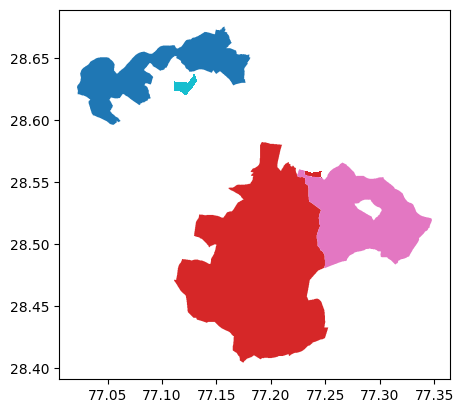

In [41]:
combined_gdf.plot(column="PCA_ID")

In [42]:
combined_gdf[["PSU Type", "Ward Count (All)", "Ward Count IFS", "Ward Count Panel", "Ward Count Panel Round 2"]]

,PSU Type,Ward Count (All),Ward Count IFS,Ward Count Panel,Ward Count Panel Round 2
0,subdistrict,1,0,0,1
1,ward,1,0,0,1
2,subdistrict,5,0,0,4
3,subdistrict,3,0,0,3


#### Add unique overall ID column

In [43]:
# add an ID column that is unique across all rows. It should be WARD_{PCA_ID} if the PSU Type is "ward", TV_{TV Code} if the PSU Type is "town_village", and SUBDISTRICT_{Subdistrict Code} if the PSU Type is "subdistrict"
combined_gdf["PSU_ID"] = combined_gdf.apply(
    lambda row: f"WARD_{row['PCA_ID']}"
    if row["PSU Type"] == "ward"
    else f"TV_{row['TV Code']}"
    if row["PSU Type"] == "town_village"
    else f"SUBDISTRICT_{row['Subdistrict Code']}",
    axis=1,
).astype(str)

In [44]:
combined_gdf[combined_gdf.duplicated(subset=["PSU_ID"], keep=False)]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,TV Code_MapSolve,TV Name,Ward Code_MapSolve,Total Population,geometry,PCA_ID_MapSolve,PSU_ID


In [45]:
combined_gdf = combined_gdf.drop_duplicates(subset=["PSU_ID"], keep="first")

In [46]:
len(combined_gdf) == combined_gdf["PSU_ID"].nunique()

True

In [47]:
combined_gdf["UID"] = combined_gdf["UID"].astype(str)

In [48]:
save_shapefiles(
    combined_gdf,
    OUTPUT_DATA_DIR / "Sampled PSUs",
    "all_sampled_PSUs",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Hastsal (CT) WARD NO.-0122' of field all_sampled_PSUs.TV Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '63991-122' of field all_sampled_PSUs.Ward Code parsed incompletely to real 63991.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Invalid value 'GOOD - Subdistrict boundary given as expected' for boolean field all_sampled_PSUs.TV Boundary Given. Assuming it to be false.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Invalid value 'subdistrict' for boolean field all_sampled_PSUs.SubDistrict Boundary Given. Assuming it to be false.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-pa

## 5. Download rooftops

### Functions

#### S2 cell shapes

In [49]:
def s2_cell_id_to_shape(s2_cell_id):
    """
    Convert an S2 cell ID to a shapely polygon.

    Parameters:
    - s2_cell_id (int): The S2 cell ID

    Returns:
    - shapely.geometry.Polygon: Polygon representing the S2 cell
    """
    # Convert string to int if necessary
    if isinstance(s2_cell_id, str):
        s2_cell_id = int(s2_cell_id)

    # Create an S2 cell from the ID
    cell = s2sphere.CellId(s2_cell_id)
    cell = s2sphere.Cell(cell)

    # Extract the vertices of the cell
    vertices = []
    for i in range(4):
        vertex = cell.get_vertex(i)
        lat_lng = s2sphere.LatLng.from_point(vertex)
        vertices.append((lat_lng.lng().degrees, lat_lng.lat().degrees))

    # Close the polygon by repeating the first vertex
    vertices.append(vertices[0])

    # Create a shapely polygon
    return Polygon(vertices)


def s2_cell_ids_to_shapes_gdf(s2_cell_ids):
    """
    Convert a list of S2 cell IDs to a GeoDataFrame with polygon geometries.

    Parameters:
    - s2_cell_ids (list): List of S2 cell IDs

    Returns:
    - geopandas.GeoDataFrame: GeoDataFrame with S2 cells as polygons
    """
    geometries = []
    for s2_id in s2_cell_ids:
        polygon = s2_cell_id_to_shape(s2_id)
        geometries.append(polygon)

    return gpd.GeoDataFrame(
        {"s2_cell_id": s2_cell_ids, "geometry": geometries}, crs="EPSG:4326"
    )

#### Find IDs of overlapping S2 cells

In [50]:
def get_s2_cell_ids_from_points(points, level=6) -> list[int]:
    """
    Get S2 cell IDs for the given points at the specified level.
    """
    # check if crs is set to WGS84 (EPSG:4326)
    if points.crs is None or points.crs.to_string() != "EPSG:4326":
        raise ValueError("Points GeoDataFrame must be in WGS84 (EPSG:4326) CRS.")

    # convert points to S2 cell IDs
    s2_cell_id_list = points.geometry.apply(
        lambda geom: lat_lon_to_cell_id(geom.y, geom.x, level)
    )
    s2_cell_ids = s2_cell_id_list.unique().tolist()

    return s2_cell_ids


def get_s2_cell_ids(gdf, level=6) -> list[int]:
    """
    Get S2 cell IDs of S2 cells that overlap the given GeoDataFrame at the specified level.

    Iteratively checks if any area is not covered by an S2 cell and continues until all areas are covered.

    Parameters:
    - gdf: GeoDataFrame in WGS84 (EPSG:4326) CRS
    - level: int

    Returns:
    - list[int]: List of S2 cell IDs
    """

    # check if crs is set to WGS84 (EPSG:4326)
    if gdf.crs is None or gdf.crs.to_string() != "EPSG:4326":
        raise ValueError("GeoDataFrame must be in WGS84 (EPSG:4326) CRS.")

    # generate initial S2 cell IDs from the GeoDataFrame centroids
    points = gdf.geometry.centroid.to_frame(name="geometry")
    s2_cell_ids = get_s2_cell_ids_from_points(points, level=level)

    # get initial S2 cell shapes and check for full coverage
    s2_cell_shapes = s2_cell_ids_to_shapes_gdf(s2_cell_ids)
    leftover_shapes = gdf.difference(s2_cell_shapes.unary_union)
    leftover_shapes = leftover_shapes[~leftover_shapes.is_empty]

    print(f"Shapes with spillover after round 1: {len(leftover_shapes)}")

    step = 2
    while len(leftover_shapes) > 0:
        # get new s2 cell IDs from the leftover shapes
        points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")
        s2_cell_ids_new = get_s2_cell_ids_from_points(points_new, level=level)

        # get new s2 cell shapes
        s2_cell_shapes = s2_cell_ids_to_shapes_gdf(s2_cell_ids_new)
        leftover_shapes = leftover_shapes.difference(s2_cell_shapes.unary_union)
        leftover_shapes = leftover_shapes[~leftover_shapes.is_empty]

        # add new s2 cell IDs to the existing list
        s2_cell_ids = s2_cell_ids + s2_cell_ids_new

        print(f"Shapes with spillover after round {step}: {len(leftover_shapes)}")
        step += 1

    return s2_cell_ids

#### Auto-download rooftop data by S2 cell ID

In [51]:
def download_VIDA_rooftops_data_by_s2_single(
    s2_cell_id: int, country_iso_code: str, target_data_dir: Path
) -> None:
    """
    Download S2 rooftops data for a given S2 cell ID from the VIDA S3 bucket. URL:
    https://beta.source.coop/vida/google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/
    """

    s2_rooftops_path = target_data_dir / f"{s2_cell_id}.parquet"

    if s2_rooftops_path.exists():
        print(f"File {s2_cell_id} already exists.")
    else:
        print(f"Downloading file for S2 cell ID: {s2_cell_id}")
        s2_rooftops_path.parent.mkdir(parents=True, exist_ok=True)
        s3 = boto3.client("s3", endpoint_url="https://data.source.coop")
        try:
            s3.download_file(
                "vida",
                f"google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso={country_iso_code}/{s2_cell_id}.parquet",
                str(s2_rooftops_path),
            )
            print(f"File {s2_cell_id} downloaded.")
        except Exception as e:
            raise RuntimeError(
                f"Failed to download file for S2 cell ID {s2_cell_id}: {e}"
            )


def download_VIDA_rooftops_data_by_s2(
    s2_cell_ids: list[int], country_iso_code: str, target_data_dir: Path
) -> None:
    """
    Download S2 rooftops data for multiple S2 cell IDs

    Parameters:
    - s2_cell_ids: list of S2 cell IDs
    - country_iso_code: ISO code of the country (e.g., "IND" for India)
    - target_data_dir: directory to save the downloaded data
    """

    for s2_cell_id in tqdm(s2_cell_ids, desc="Downloading rooftops by S2 cell"):
        download_VIDA_rooftops_data_by_s2_single(
            s2_cell_id, country_iso_code, target_data_dir
        )

### Run

#### Identify S2 cell IDs

In [52]:
s2_cell_ids = get_s2_cell_ids(combined_gdf)
len(s2_cell_ids)

Shapes with spillover after round 1: 0


/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_35416/1927699269.py:37: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")


1

#### Check if identified cells cover all areas of interest

In [53]:
s2_cells_gdf = s2_cell_ids_to_shapes_gdf(s2_cell_ids)

In [54]:
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = combined_gdf.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")

0.0 square degrees area not covered by an S2 cell


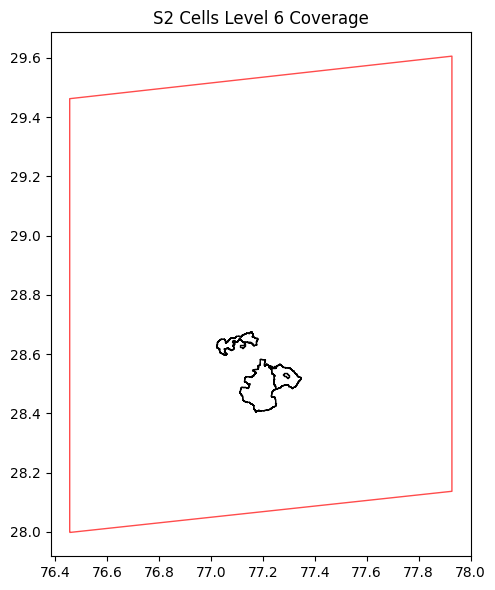

In [55]:
# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
combined_gdf.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()

In [56]:
s2_cells_gdf_w_state = (
    s2_cells_gdf.sjoin(
        combined_gdf[["State Name", "geometry"]], how="inner", predicate="intersects"
    )
    .drop(columns="index_right")
    .drop_duplicates()
)

In [57]:
# note: this will have duplicate s2 cell rows with different state names if the s2 cell overlaps multiple states
# this is expected and is required for the next steps logic to work correctly
s2_cells_gdf_w_state

,s2_cell_id,geometry,State Name
0,4110942034859130880,"POLYGON ((76.45631 27.99812, 77.92817 28.13705...",NCT of Delhi


#### Download the S2 cells

In [58]:
download_VIDA_rooftops_data_by_s2(s2_cell_ids, "IND", RAW_DATA_DIR / "02. Rooftop Data")

File 4110942034859130880 already exists.


## 6. Load rooftops and match to areas

In [59]:
def get_matched_rooftop_centroids_from_s2_file(
    s2_cell_id: int, boundaries_gdf: gpd.GeoDataFrame
) -> gpd.GeoDataFrame:
    """
    Get rooftops from the S2 cell file that match the boundaries:
    1. loads the rooftops data for the specified S2 cell ID
    2. filters the rooftops to only those that intersect with the boundaries
    3. returns a GeoDataFrame of the matched rooftops centroids with unique IDs

    Parameters:
    - s2_cell_id (int): The S2 cell ID to filter rooftops for.
    - boundaries_gdf (gpd.GeoDataFrame): The GeoDataFrame containing the boundaries.
    """

    # load the rooftops data for the S2 cell
    s2_rooftops_path = RAW_DATA_DIR / "02. Rooftop Data" / f"{s2_cell_id}.parquet"
    s2_rooftops_gdf = gpd.read_parquet(s2_rooftops_path)

    # replace polygons with just the centroid of the rooftops
    s2_rooftop_centroids_gdf = s2_rooftops_gdf.set_geometry(
        s2_rooftops_gdf.geometry.centroid
    )

    # filter the boundaries dataset to only the shapes that overlap the S2 cell
    s2_cell_polygon = s2_cell_id_to_shape(s2_cell_id)
    boundaries_gdf_s2_overlap = boundaries_gdf[
        boundaries_gdf.intersects(s2_cell_polygon)
    ]

    # perform a spatial join to filter and add area metadata to the rooftops
    matched_rooftop_centroids_gdf = gpd.sjoin(
        s2_rooftop_centroids_gdf,
        boundaries_gdf_s2_overlap,
        how="inner",
        predicate="within",
    ).drop(columns=["index_right"])

    # add IDs to each rooftop
    matched_rooftop_centroids_gdf["s2_rooftop_id"] = create_ids(
        len(matched_rooftop_centroids_gdf), f"S2_{s2_cell_id}_ROOFTOP_"
    )

    return matched_rooftop_centroids_gdf

In [60]:
state_names = combined_gdf["State Name"].sort_values().unique()

for state_name in tqdm(state_names):
    print(f"Processing state: {state_name}")

    # Filter the s2 cells and rooftops gdf to the current state
    s2_cell_ids = set(
        s2_cells_gdf_w_state[s2_cells_gdf_w_state["State Name"] == state_name][
            "s2_cell_id"
        ]
    )
    print(
        f"Number of S2 cells that overlap our shapes in {state_name}: {len(s2_cell_ids)}"
    )
    gdf_subset = combined_gdf[combined_gdf["State Name"] == state_name]

    # Get matched rooftops for each S2 cell in the state
    matched_rooftop_centroids_gdf_list = []
    for s2_cell_id in tqdm(s2_cell_ids):
        matched_rooftop_centroids_gdf = get_matched_rooftop_centroids_from_s2_file(
            s2_cell_id, gdf_subset
        )
        matched_rooftop_centroids_gdf_list.append(matched_rooftop_centroids_gdf)
    matched_rooftop_centroids_gdf = pd.concat(
        matched_rooftop_centroids_gdf_list, ignore_index=True
    )
    matched_rooftop_centroids_gdf["State Name"] = state_name

    # Save the matched rooftops data
    save_shapefiles(
        matched_rooftop_centroids_gdf,
        CLEANED_DATA_DIR / "01. Matched Rooftop Data" / f"{state_name}",
        "matched_rooftops",
        ["parquet"],
    )

  0%|          | 0/1 [00:00<?, ?it/s]

Processing state: NCT of Delhi
Number of S2 cells that overlap our shapes in NCT of Delhi: 1


  0%|          | 0/1 [00:00<?, ?it/s]

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_35416/207331629.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid


<Axes: >

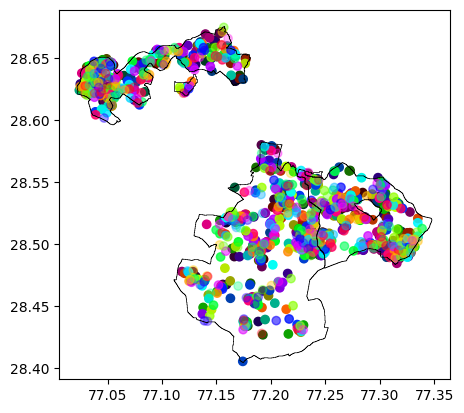

In [61]:
ax = matched_rooftop_centroids_gdf.sample(1000).plot(
    cmap=ListedColormap(generate_colormap(len(matched_rooftop_centroids_gdf))),
)
gdf_subset.plot(ax=ax, color="none", edgecolor="black", linewidth=0.5)

## 7. Load matched rooftops

In [62]:
matched_rooftop_dir = CLEANED_DATA_DIR / "01. Matched Rooftop Data"
all_filepaths = list(matched_rooftop_dir.glob("**/*.parquet"))
all_filepaths = [f for f in all_filepaths if f.is_file()]

# filter to those that have selected_states in the name
all_filepaths = [
    f for f in all_filepaths if any(state in f.parent.name for state in selected_states)
]

# load all shapes into one gdf
matched_rooftops_gdf_list = []
for filepath in tqdm(all_filepaths):
    matched_rooftops_gdf_list.append(gpd.read_parquet(filepath))
matched_rooftops_gdf = gpd.GeoDataFrame(
    pd.concat(matched_rooftops_gdf_list, ignore_index=True)
).to_crs(4326)

  0%|          | 0/1 [00:00<?, ?it/s]

In [63]:
len(matched_rooftops_gdf)

510319

In [64]:
matched_rooftops_gdf["State Name"].unique()

array(['NCT of Delhi'], dtype=object)

In [65]:
no_rooftop_PSU_IDs = set(combined_gdf["PSU_ID"].unique()).difference(set(matched_rooftops_gdf["PSU_ID"].unique()))
no_rooftop_PSU_gdf = combined_gdf[combined_gdf["PSU_ID"].isin(no_rooftop_PSU_IDs)]
no_rooftop_PSU_gdf

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,TV Code_MapSolve,TV Name,Ward Code_MapSolve,Total Population,geometry,PCA_ID_MapSolve,PSU_ID


In [66]:
no_rooftop_PSU_gdf.to_csv(
    OUTPUT_DATA_DIR / "Sampled PSUs" / "PSU_IDs_with_no_rooftops.csv",
    index=False,
)

## 8. Sample rooftops

### Filters

In [68]:
# # filter to missing TV
# matched_rooftops_gdf = matched_rooftops_gdf[matched_rooftops_gdf["PCA_ID"].isin(pca_ids) | matched_rooftops_gdf["TV Code"].isin(tv_ids)]

In [69]:
matched_rooftops_gdf["PSU_ID"].unique()

array(['SUBDISTRICT_454.0', 'SUBDISTRICT_448.0', 'WARD_800441-111',
       'SUBDISTRICT_456.0'], dtype=object)

### Do the sampling

In [70]:
# Define the base number of rooftops per ward
ROOFTOPS_PER_WARD = 25

# Sample rooftops, multiplying by Ward Count for each PSU. 
sampled_rooftops = matched_rooftops_gdf.groupby(
    "PSU_ID", group_keys=False
).apply(
    lambda x: x.sample(
        n=min(ROOFTOPS_PER_WARD, x.shape[0]),
        random_state=42
    )
)

In [71]:
# Red's code expects the column to be named "Ward Count" instead of "Ward Count Panel"
sampled_rooftops["Ward Count"] = 1

In [73]:
sampled_rooftops["PCA_ID"].value_counts()

PCA_ID
63991-122     25
64072-174     25
64084-202     25
800441-111    25
Name: count, dtype: int64

### Add sample-level rooftop numbering ID columns

In [74]:
# Rooftop number within each state
sampled_rooftops["Rooftop State ID"] = (
    sampled_rooftops.groupby("State Name").cumcount() + 1
)

# Rooftop number within each PSU_ID
sampled_rooftops["Rooftop PSU ID"] = sampled_rooftops.groupby("PSU_ID").cumcount() + 1
# add prefix of "PIN "  to the Rooftop PSU ID
sampled_rooftops["Rooftop PSU ID"] = "PIN " + sampled_rooftops["Rooftop PSU ID"].astype(str)

# Rooftop unique ID
sampled_rooftops["Rooftop Unique ID"] = sampled_rooftops.apply(
    lambda row: f"STATE_{row['Rooftop State ID']}_PSU_ID_{row['PSU_ID']}_ROOFTOP_{row['Rooftop PSU ID']}",
    axis=1,
)

### Add gmap link

In [75]:
sampled_rooftops["latitude"] = sampled_rooftops.geometry.y
sampled_rooftops["longitude"] = sampled_rooftops.geometry.x
sampled_rooftops["gmap_link"] = create_gmap_links(
    df=sampled_rooftops,
    lat_name="latitude",
    lon_name="longitude",
)

### Select only useful columns

**Required columns:**
- PSU info
    - Unique ID across all rooftops
    - Rooftop state ID, #
    - Rooftop PSU_ID, #

    - PSU Unit: Ward, TV, Subdistrict
    - PSU sample size

- geospatial info
    - google maps link
    - coordinates
    - geometry

- Admin location info
    - State code and name
    - District code and Name
    - Subdistrict code and name
    - TV code and name
    - Ward code and name

In [76]:
chosen_cols = [
    ## IDs
    "Rooftop State ID",
    "Rooftop PSU ID",
    "Rooftop Unique ID",

    ## Geospatial data
    "geometry",
    "latitude",
    "longitude",
    "gmap_link",

    ## PSU info
    "PSU_ID",
    "PSU Type",
    "Ward Count", # IFS only
    "Ward Count (All)",  # both IFS and Panel and Panel Round 2

    ## Location info
    "State Code",
    "State Name",
    "State Changed",
    "District Code",
    "District Name",
    "Subdistrict Code",
    "Subdistrict Name",
    "TV Code",
    "TV Name",  # (from MapSolve)
    "Ward Code",
    "Ward/Village Name",
    "Urban/Rural",
    "PCA_ID",  # combined TVCode-WardCode
    "Ward Population",
    "Subdistrict Population",
    "State Population",
    # "Complete ID",

    ## Admin information
    # "Sampled for Panel",
    # "Sampled for IFS",
    "Ward Boundary Available with MapSolve",
    # "Source Sheet",
    # "State Shared by MapSolve",
    "Ward Boundary Given",
    "TV Boundary Given",
    "SubDistrict Boundary Given",
    "Delivery State",
    # "UID",
    # "s2_rooftop_id",

    ## MapSolve location info
    "State Code_MapSolve",
    "State Name_MapSolve",
    "District Code_MapSolve",
    "District Name_MapSolve",
    "Subdistrict Code_MapSolve",
    "Subdistrict Name_MapSolve",
    # "TV Code_MapSolve",
    # "TV Name",
    "Ward Code_MapSolve",
    "PCA_ID_MapSolve",
    "Total Population",

    # ## rooftop info
    # "boundary_id",
    # "bf_source",
    # "confidence",
    # "area_in_meters",
    # "s2_id",
    # "country_iso",
    # "geohash",
    # "bbox",
]

In [77]:
sampled_rooftops_organised_gdf = sampled_rooftops[chosen_cols]

In [78]:
sampled_rooftops_organised_gdf.rename(
    columns={
        "TV Name": "TV Name_MapSolve",
        "PSU_ID" : "PSU ID",
        "Total Population": "PSU Total Population_MapSolve",
    },
    inplace=True,
)

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_35416/1139571638.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sampled_rooftops_organised_gdf.rename(


In [79]:
# set Ward Codes of 0.0 to NaN
sampled_rooftops_organised_gdf.loc[
    sampled_rooftops_organised_gdf["Ward Code"] == 0.0, "Ward Code"
] = np.nan

In [80]:
sampled_rooftops_organised_gdf

,Rooftop State ID,Rooftop PSU ID,Rooftop Unique ID,geometry,latitude,longitude,gmap_link,PSU ID,PSU Type,Ward Count,...,Delivery State,State Code_MapSolve,State Name_MapSolve,District Code_MapSolve,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,Ward Code_MapSolve,PCA_ID_MapSolve,PSU Total Population_MapSolve
300804,1,PIN 1,STATE_1_PSU_ID_SUBDISTRICT_448.0_ROOFTOP_PIN 1,POINT (77.13152 28.65193),28.651928,77.131519,https://www.google.com/maps/search/?api=1&quer...,SUBDISTRICT_448.0,subdistrict,1,...,GOOD - Subdistrict boundary given as expected,7.0,NCT of Delhi,96.0,West,NaN,Patel Nagar,NaN,7-96-448,1262158.0
293173,2,PIN 2,STATE_2_PSU_ID_SUBDISTRICT_448.0_ROOFTOP_PIN 2,POINT (77.10425 28.65186),28.651863,77.104254,https://www.google.com/maps/search/?api=1&quer...,SUBDISTRICT_448.0,subdistrict,1,...,GOOD - Subdistrict boundary given as expected,7.0,NCT of Delhi,96.0,West,NaN,Patel Nagar,NaN,7-96-448,1262158.0
321458,3,PIN 3,STATE_3_PSU_ID_SUBDISTRICT_448.0_ROOFTOP_PIN 3,POINT (77.10309 28.65878),28.658777,77.103089,https://www.google.com/maps/search/?api=1&quer...,SUBDISTRICT_448.0,subdistrict,1,...,GOOD - Subdistrict boundary given as expected,7.0,NCT of Delhi,96.0,West,NaN,Patel Nagar,NaN,7-96-448,1262158.0
344305,4,PIN 4,STATE_4_PSU_ID_SUBDISTRICT_448.0_ROOFTOP_PIN 4,POINT (77.16187 28.66111),28.661106,77.161866,https://www.google.com/maps/search/?api=1&quer...,SUBDISTRICT_448.0,subdistrict,1,...,GOOD - Subdistrict boundary given as expected,7.0,NCT of Delhi,96.0,West,NaN,Patel Nagar,NaN,7-96-448,1262158.0
203168,5,PIN 5,STATE_5_PSU_ID_SUBDISTRICT_448.0_ROOFTOP_PIN 5,POINT (77.03491 28.63005),28.630049,77.034914,https://www.google.com/maps/search/?api=1&quer...,SUBDISTRICT_448.0,subdistrict,1,...,GOOD - Subdistrict boundary given as expected,7.0,NCT of Delhi,96.0,West,NaN,Patel Nagar,NaN,7-96-448,1262158.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349418,96,PIN 21,STATE_96_PSU_ID_WARD_800441-111_ROOFTOP_PIN 21,POINT (77.11390 28.62776),28.627763,77.113898,https://www.google.com/maps/search/?api=1&quer...,WARD_800441-111,ward,1,...,GOOD - Ward boundary given as expected,7.0,Delhi,NaN,None,NaN,None,111.0,None,52346.0
347949,97,PIN 22,STATE_97_PSU_ID_WARD_800441-111_ROOFTOP_PIN 22,POINT (77.11172 28.62860),28.628597,77.111720,https://www.google.com/maps/search/?api=1&quer...,WARD_800441-111,ward,1,...,GOOD - Ward boundary given as expected,7.0,Delhi,NaN,None,NaN,None,111.0,None,52346.0
351738,98,PIN 23,STATE_98_PSU_ID_WARD_800441-111_ROOFTOP_PIN 23,POINT (77.12720 28.63252),28.632524,77.127202,https://www.google.com/maps/search/?api=1&quer...,WARD_800441-111,ward,1,...,GOOD - Ward boundary given as expected,7.0,Delhi,NaN,None,NaN,None,111.0,None,52346.0
351260,99,PIN 24,STATE_99_PSU_ID_WARD_800441-111_ROOFTOP_PIN 24,POINT (77.12626 28.62845),28.628453,77.126255,https://www.google.com/maps/search/?api=1&quer...,WARD_800441-111,ward,1,...,GOOD - Ward boundary given as expected,7.0,Delhi,NaN,None,NaN,None,111.0,None,52346.0


### Save sampled data (original rooftop pins)

In [81]:
save_shapefiles(
    sampled_rooftops_organised_gdf,
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_centroids_original",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=28.6519283089702,77.13151886158609' of field sampled_rooftops_centroids_original.latitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'SUBDISTRICT_448.0' of field sampled_rooftops_centroids_original.longitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field sampled_rooftops_centroids_original.State Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Urban' of field sampled_rooftops_centroids_original.Ward Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/ve

## 9. Snap points to road

### Functions

In [82]:
from shapely import Point
import requests
from concurrent.futures import ThreadPoolExecutor


def get_nearest_point_on_road(point: Point, api_key: str) -> Point | None:
    """
    Retrieves the nearest point on the road for a given point using the Google Roads API.

    Args:
        point (Point): The point for which to find the nearest point on the road.
        api_key (str): Your Google Roads API key.

    Returns:
        Point: The nearest point on the road, or None if no point is found.

    """
    url = f"https://roads.googleapis.com/v1/snapToRoads?path={point.y},{point.x}&key={api_key}"
    response = requests.get(url)
    snapped_point = response.json().get("snappedPoints", [{}])[0].get("location")
    return (
        Point(snapped_point["longitude"], snapped_point["latitude"])
        if snapped_point
        else None
    )

def snap_point_to_road(args):
    """Helper function to snap a point to the nearest road."""
    idx, point, api_key = args
    try:
        snapped_point = get_nearest_point_on_road(point, api_key)
        return idx, snapped_point
    except Exception as e:
        print(f"Error snapping point at index {idx}: {str(e)}")
        return idx, None

def snap_points_to_roads_parallel(gdf, api_key, max_workers=10) -> gpd.GeoSeries:
    """
    Snap all points in a GeoDataFrame to the nearest road using parallel processing.
    
    Args:
        gdf: GeoDataFrame containing point geometries
        api_key: Google Roads API key
        max_workers: Number of parallel workers
        
    Returns:
        GeoSeries with snapped geometries
    """
    # Prepare arguments for parallel processing
    args_list = [(idx, point, api_key) for idx, point in enumerate(gdf.geometry)]
    
    # Initialize results dictionary
    snapped_points = {}
    
    # Process in parallel with progress bar
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # Submit all tasks and track with tqdm
        results = list(tqdm(
            executor.map(snap_point_to_road, args_list), 
            total=len(args_list),
            desc="Snapping points to roads"
        ))
    
    # Process results
    for idx, snapped_point in results:
        snapped_points[idx] = snapped_point
    snapped_points_series = gpd.GeoSeries(snapped_points)

    return snapped_points_series

### Run

In [83]:
# load API key
import yaml
with open('../secrets/api_keys.yaml', 'r') as f:
    config = yaml.safe_load(f)
    api_key = config['GOOGLE_ROADS_API_KEY']

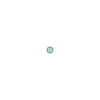

In [84]:
get_nearest_point_on_road(
    Point(77.11432151622034, 28.677391409999522), api_key
)

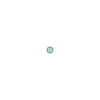

In [85]:
# test
get_nearest_point_on_road(
    sampled_rooftops_organised_gdf.geometry.iloc[0], api_key
)

In [86]:
len(sampled_rooftops_organised_gdf)

100

#### Snap points to road

In [87]:
snapped_points_series = snap_points_to_roads_parallel(
    sampled_rooftops_organised_gdf, 
    api_key,
    max_workers=12
)
# took 1min for 3,200 points

Snapping points to roads:   0%|          | 0/100 [00:00<?, ?it/s]

In [88]:
sampled_rooftops_snapped_gdf = sampled_rooftops_organised_gdf.copy()
sampled_rooftops_snapped_gdf["geometry_snapped"] = list(snapped_points_series)

In [89]:
# Make new Geometry Type column which has values "Original" or "Snapped to Road"
sampled_rooftops_snapped_gdf["Geometry Type"] = (
    sampled_rooftops_snapped_gdf["geometry_snapped"]
    .notna()
    .replace({True: "Snapped to Road", False: "Original"})
)
sampled_rooftops_snapped_gdf["Geometry Type"].value_counts()

Geometry Type
Snapped to Road    100
Name: count, dtype: int64

In [90]:
sampled_rooftops_snapped_gdf

,Rooftop State ID,Rooftop PSU ID,Rooftop Unique ID,geometry,latitude,longitude,gmap_link,PSU ID,PSU Type,Ward Count,...,State Name_MapSolve,District Code_MapSolve,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,Ward Code_MapSolve,PCA_ID_MapSolve,PSU Total Population_MapSolve,geometry_snapped,Geometry Type
300804,1,PIN 1,STATE_1_PSU_ID_SUBDISTRICT_448.0_ROOFTOP_PIN 1,POINT (77.13152 28.65193),28.651928,77.131519,https://www.google.com/maps/search/?api=1&quer...,SUBDISTRICT_448.0,subdistrict,1,...,NCT of Delhi,96.0,West,NaN,Patel Nagar,NaN,7-96-448,1262158.0,POINT (77.13159414402021 28.651947942536548),Snapped to Road
293173,2,PIN 2,STATE_2_PSU_ID_SUBDISTRICT_448.0_ROOFTOP_PIN 2,POINT (77.10425 28.65186),28.651863,77.104254,https://www.google.com/maps/search/?api=1&quer...,SUBDISTRICT_448.0,subdistrict,1,...,NCT of Delhi,96.0,West,NaN,Patel Nagar,NaN,7-96-448,1262158.0,POINT (77.10410458141268 28.651863791670245),Snapped to Road
321458,3,PIN 3,STATE_3_PSU_ID_SUBDISTRICT_448.0_ROOFTOP_PIN 3,POINT (77.10309 28.65878),28.658777,77.103089,https://www.google.com/maps/search/?api=1&quer...,SUBDISTRICT_448.0,subdistrict,1,...,NCT of Delhi,96.0,West,NaN,Patel Nagar,NaN,7-96-448,1262158.0,POINT (77.103084636386 28.6586944969846),Snapped to Road
344305,4,PIN 4,STATE_4_PSU_ID_SUBDISTRICT_448.0_ROOFTOP_PIN 4,POINT (77.16187 28.66111),28.661106,77.161866,https://www.google.com/maps/search/?api=1&quer...,SUBDISTRICT_448.0,subdistrict,1,...,NCT of Delhi,96.0,West,NaN,Patel Nagar,NaN,7-96-448,1262158.0,POINT (77.16182347796362 28.661209127607336),Snapped to Road
203168,5,PIN 5,STATE_5_PSU_ID_SUBDISTRICT_448.0_ROOFTOP_PIN 5,POINT (77.03491 28.63005),28.630049,77.034914,https://www.google.com/maps/search/?api=1&quer...,SUBDISTRICT_448.0,subdistrict,1,...,NCT of Delhi,96.0,West,NaN,Patel Nagar,NaN,7-96-448,1262158.0,POINT (77.0349162235162 28.630098006437144),Snapped to Road
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349418,96,PIN 21,STATE_96_PSU_ID_WARD_800441-111_ROOFTOP_PIN 21,POINT (77.11390 28.62776),28.627763,77.113898,https://www.google.com/maps/search/?api=1&quer...,WARD_800441-111,ward,1,...,Delhi,NaN,None,NaN,None,111.0,None,52346.0,POINT (77.11367712066013 28.62777029306724),Snapped to Road
347949,97,PIN 22,STATE_97_PSU_ID_WARD_800441-111_ROOFTOP_PIN 22,POINT (77.11172 28.62860),28.628597,77.111720,https://www.google.com/maps/search/?api=1&quer...,WARD_800441-111,ward,1,...,Delhi,NaN,None,NaN,None,111.0,None,52346.0,POINT (77.11171898372841 28.6285075145982),Snapped to Road
351738,98,PIN 23,STATE_98_PSU_ID_WARD_800441-111_ROOFTOP_PIN 23,POINT (77.12720 28.63252),28.632524,77.127202,https://www.google.com/maps/search/?api=1&quer...,WARD_800441-111,ward,1,...,Delhi,NaN,None,NaN,None,111.0,None,52346.0,POINT (77.12721703494589 28.63251359690635),Snapped to Road
351260,99,PIN 24,STATE_99_PSU_ID_WARD_800441-111_ROOFTOP_PIN 24,POINT (77.12626 28.62845),28.628453,77.126255,https://www.google.com/maps/search/?api=1&quer...,WARD_800441-111,ward,1,...,Delhi,NaN,None,NaN,None,111.0,None,52346.0,POINT (77.12626280932477 28.628173612522854),Snapped to Road


#### Replace geometry to snapped one (missing filled in with original)

In [91]:
# backup the original geometry
sampled_rooftops_snapped_gdf["geometry_original"] = sampled_rooftops_snapped_gdf[
    "geometry"
]
# replace the original geometry with the snapped geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry_snapped"
]
# drop the snapped geometry column
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf.drop(
    columns=["geometry_snapped"]
)
# fill in NaN values in the snapped geometry with the original geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry"
].fillna(sampled_rooftops_snapped_gdf["geometry_original"])

In [92]:
sampled_rooftops_snapped_gdf["geometry"].isna().sum()

0

#### Update lat, lon, gmap_link

In [93]:
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf.rename(
    columns={
        "latitude": "latitude_original",
        "longitude": "longitude_original",
        "gmap_link": "gmap_link_original",
    },
)

In [94]:
sampled_rooftops_snapped_gdf["latitude"] = list(
    sampled_rooftops_snapped_gdf.geometry.y
)
sampled_rooftops_snapped_gdf["longitude"] = list(
    sampled_rooftops_snapped_gdf.geometry.x
)
sampled_rooftops_snapped_gdf["gmap_link"] = create_gmap_links(
    df=sampled_rooftops_snapped_gdf,
    lat_name="latitude",
    lon_name="longitude",
)

#### Reorganise

In [95]:
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf[
    [
        "Rooftop State ID",
        "Rooftop PSU ID",
        "Rooftop Unique ID",
        # new columns start
        "Geometry Type",
        "geometry",
        "latitude",
        "longitude",
        "gmap_link",
        # new columns end
        "geometry_original",
        "latitude_original",
        "longitude_original",
        "gmap_link_original",
        "PSU ID",
        "PSU Type",
        "Ward Count", # IFS only
        "Ward Count (All)",  # IFS and Panel and Panel Round 2
        "State Code",
        "State Name",
        "State Changed",
        "District Code",
        "District Name",
        "Subdistrict Code",
        "Subdistrict Name",
        "TV Code",
        "TV Name_MapSolve",
        "Ward Code",
        "Ward/Village Name",
        "Urban/Rural",
        "PCA_ID",
        "Ward Population",
        "Subdistrict Population",
        "State Population",
        "Ward Boundary Available with MapSolve",
        "Ward Boundary Given",
        "TV Boundary Given",
        "SubDistrict Boundary Given",
        "Delivery State",
        "State Code_MapSolve",
        "State Name_MapSolve",
        "District Code_MapSolve",
        "District Name_MapSolve",
        "Subdistrict Code_MapSolve",
        "Subdistrict Name_MapSolve",
        # "TV Code_MapSolve",
        "Ward Code_MapSolve",
        "PCA_ID_MapSolve",
        "PSU Total Population_MapSolve",
    ]
]

#### Make lines between original and snapped points

In [96]:
from shapely.geometry import LineString

In [97]:
sampled_rooftops_snapped_gdf["geometry_line"] = sampled_rooftops_snapped_gdf.apply(
    lambda row: LineString([row["geometry_original"], row["geometry"]]), axis=1
)

In [98]:
sampled_rooftops_snapped_gdf["geometry_line"].isna().sum()

0

#### Save new files: snapped points, snapped lines

In [99]:
# Save snapped points
save_shapefiles(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_points",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=28.651947942536548,77.13159414402021' of field sampled_rooftops_snapped_points.latitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=28.6519283089702,77.13151886158609' of field sampled_rooftops_snapped_points.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'SUBDISTRICT_448.0' of field sampled_rooftops_snapped_points.longitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field sampled_rooftops_snapped_points.S

In [100]:
# Save lines
sampled_rooftops_line_gdf = sampled_rooftops_snapped_gdf.copy()
sampled_rooftops_line_gdf["geometry"] = sampled_rooftops_line_gdf["geometry_line"]
save_shapefiles(
    sampled_rooftops_line_gdf.drop(
    columns=["geometry_line", "geometry_original"]
),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_lines",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=28.651947942536548,77.13159414402021' of field sampled_rooftops_snapped_lines.latitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=28.6519283089702,77.13151886158609' of field sampled_rooftops_snapped_lines.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'SUBDISTRICT_448.0' of field sampled_rooftops_snapped_lines.longitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field sampled_rooftops_snapped_lines.State

## Save per state

In [101]:
for state in sampled_rooftops_organised_gdf["State Name"].unique():
    state_output_folder = OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / state
    save_shapefiles(
        sampled_rooftops_organised_gdf[
            sampled_rooftops_organised_gdf["State Name"] == state
        ],
        state_output_folder,
        f"{state}_sampled_rooftops_centroids_original",
        ["csv", "parquet", "kml"],
    )

    # Save snapped points
    save_shapefiles(
        sampled_rooftops_snapped_gdf[
            sampled_rooftops_snapped_gdf["State Name"] == state
        ].drop(
            columns=[
                "geometry_original",
                "geometry_line",
            ]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_points",
        ["csv", "parquet", "kml"],
    )

    # Save lines
    sampled_rooftops_line_gdf = sampled_rooftops_snapped_gdf.copy()
    sampled_rooftops_line_gdf["geometry"] = sampled_rooftops_line_gdf["geometry_line"]
    save_shapefiles(
        sampled_rooftops_line_gdf[
            sampled_rooftops_line_gdf["State Name"] == state
        ].drop(columns=["geometry_line", "geometry_original"]),
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_lines",
        ["csv", "parquet", "kml"],
    )

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Layer name 'NCT of Delhi_sampled_rooftops_centroids_original' adjusted to 'NCT_of_Delhi_sampled_rooftops_centroids_original' for XML validity.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=28.6519283089702,77.13151886158609' of field NCT_of_Delhi_sampled_rooftops_centroids_original.latitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'SUBDISTRICT_448.0' of field NCT_of_Delhi_sampled_rooftops_centroids_original.longitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field NCT_of_Delhi_sampled_rooftops_centroids_original